# import libraries

In [52]:
import keras
import pandas as pd
from matplotlib import pyplot as plt
from keras.models import Sequential
from keras.layers import Flatten,Dense
import numpy as np
from PIL import Image

# Data Collection

In [9]:
(x_train, y_train), (x_test, y_test)=keras.datasets.mnist.load_data()

# Data Understanding

In [15]:
x_train.shape,y_train.shape

((60000, 28, 28), (60000,))

In [17]:
x_test.shape,y_test.shape

((10000, 28, 28), (10000,))

In [18]:
assert x_train.shape == (60000, 28, 28)

### Seeing image

In [23]:
pd.set_option("display.max_columns",30)

In [24]:
pd.DataFrame(x_train[1])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,51,159,253,159,50,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,48,238,252,252,252,237,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,54,227,253,252,239,233,252,57,6,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,10,60,224,252,253,252,202,84,252,253,122,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,163,252,252,252,253,252,252,96,189,253,167,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,51,238,253,253,190,114,253,228,47,79,255,168,0,0,0,0,0,0


In [25]:
y_train[1]

np.uint8(0)

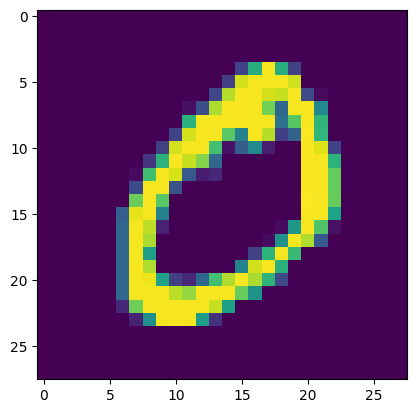

In [26]:
plt.imshow(x_train[1])

# Data Preparation

### Normalising for faster processing

In [27]:
x_train = x_train/255.0
x_test = x_test / 255.0

In [30]:
x_test.min()

np.float64(0.0)

# Model Building

In [36]:
model = Sequential() # --> --> --->
model.add(Flatten()) # flatting one by one
model.add(Dense(units =100 ,activation="relu")) # Hidden layer -1(use dense for adding layer)
model.add(Dense(units =10 ,activation="softmax"))   # output layer (only 10 units because only 10 labbeled output)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(optimizer='rmsprop',loss='sparse_categorical_crossentropy',metrics=["sparse_categorical_accuracy"])

# Model Traning | Model Testing | Model Evaluation

In [38]:
model.fit(  x=x_train,y=y_train,batch_size=30,epochs=10,validation_data =(x_test,y_test) )

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.2734 - sparse_categorical_accuracy: 0.9205 - val_loss: 0.1544 - val_sparse_categorical_accuracy: 0.9538
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1336 - sparse_categorical_accuracy: 0.9607 - val_loss: 0.1127 - val_sparse_categorical_accuracy: 0.9670
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0990 - sparse_categorical_accuracy: 0.9704 - val_loss: 0.0974 - val_sparse_categorical_accuracy: 0.9727
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0796 - sparse_categorical_accuracy: 0.9766 - val_loss: 0.0958 - val_sparse_categorical_accuracy: 0.9715
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0676 - sparse_categorical_accuracy: 0.9805 - val_loss: 0.0895 - val_sparse_categorical_accuracy: 0.9749
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0592 - sparse_categorical_accuracy: 0.9830 - val_loss: 0.0858 - val_sparse_categorical_accuracy

In [39]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (30, 784)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (30, 100)                   │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (30, 10)                    │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 159,022 (621.18 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 79,512 (310.60 KB)

# Manual model prediction

In [40]:
y_pred_test = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [41]:
y_test[500]

np.uint8(3)

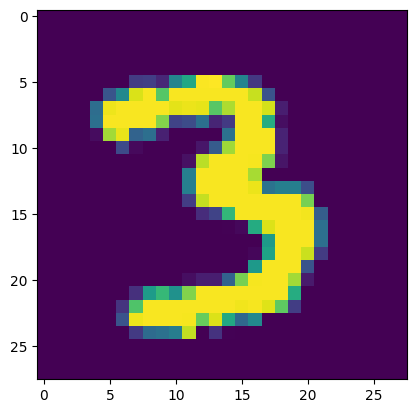

In [43]:
plt.imshow(x_test[500])

In [46]:
np.argmax(y_pred_test[500])

np.int64(3)

# Checking the outside new data

In [47]:
model.save("digits_intel.h5")  # saving intel file

### Loading image

In [54]:
img_path = r"D:\Screenshot 2026-09-11 120515.jpg"

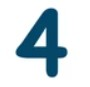

In [56]:
image = Image.open(img_path)
image

In [57]:
image.size

(90, 87)

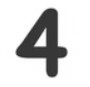

In [60]:
image = image.convert(mode = "L")
image

In [63]:
image = image.resize(size = (28,28))
image

In [64]:
image.size

(28, 28)

In [66]:
image = np.array(image)

In [67]:
image

array([[255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 254,
        255, 255, 254, 253, 254, 254, 254, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 255, 254, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 254, 254,
        255, 232, 185, 190, 242, 255, 254, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 254, 254, 255,
        202,  83,  50,  49, 126, 250, 255, 254, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 254, 255, 230,
         81,  47,  54,  50,  73, 235, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 254, 254, 254, 254, 255, 254, 252, 129,
         47,  54,  54,  51,  76, 234, 255, 255, 255, 254, 255, 255, 255,
        255, 255],
       [25

In [ ]:
#image = image.convert(mode = "L").resize(size=(28,28)) ----> chain comment

# Doing predicts

In [65]:
from keras.models import load_model
load_model = load_model("digits_intel.h5")

In [70]:
def predict_image(image):
    image = image/255.0
    print(image.shape)
    image = np.expand_dims(a = image,axis = 0)
    print(image.shape)
    predic = load_model.predict(image)
    
    return np.argmax(predic)

In [71]:
predict_image(image)

(28, 28)
(1, 28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


np.int64(2)